In [1630]:
from pathlib import Path
import zipfile
import shelve
import numpy as np
import pandas as pd
import shapely
import geopandas
import contextily as cx
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [1631]:
sns.set_theme(palette='Set2')

## Ingest Data

In [1632]:
# shelve cache comes zipped in github repo if cloned
# unzip if not already, access cache file
cache_filepath = 'cache/process_properties'
if not Path(cache_filepath).is_file():
    with zipfile.ZipFile('cache.zip', 'r') as cache_zip:
        cache_zip.extract(cache_filepath)
with shelve.open('cache/process_properties') as cache:
    props_full = cache['props_geo']
    owners = cache['prop_owners']
    g_owners = cache['prop_owners_top_geo']

In [1633]:
# repeat column selection from export step
select_cols = ['geometry', 'GEO_MERGE_KEY', 'FUZZY_KEY', 'FULL_ADDRE',
                  'PROPERTYHOUSENUM', 'PROPERTYFRACTION', 'PROPERTYUNIT', 'PROPERTYADDRESS', 'PROPERTYCITY', 'PROPERTYZIP', 
                  'MUNIDESC', 'NEIGHDESC', 
                  'TAXCODE', 'OWNER_ID', 'OWNERDESC',
                  'CLASS', 'USECODE', 'USEDESC',
                  'FAIRMARKETTOTAL', 'SALEDATE', 'SALEPRICE', 'PREVSALEDATE', 'PREVSALEPRICE', 'PREVSALEDATE2', 'PREVSALEPRICE2',
                  'STYLEDESC', 'YEARBLT', 'LOTAREA', 'STORIES', 'TOTALROOMS', 'GRADE', 'CONDITION', 'CDUDESC']
props = props_full[select_cols]
del props_full

In [1634]:
props.head(3)

,geometry,GEO_MERGE_KEY,FUZZY_KEY,FULL_ADDRE,PROPERTYHOUSENUM,PROPERTYFRACTION,PROPERTYUNIT,PROPERTYADDRESS,PROPERTYCITY,PROPERTYZIP,...,PREVSALEDATE2,PREVSALEPRICE2,STYLEDESC,YEARBLT,LOTAREA,STORIES,TOTALROOMS,GRADE,CONDITION,CDUDESC
0001C00167000000,POINT (1340992.9 411472.3),444 LIBERTY AVE 15222,NaN,444 LIBERTY AVE,444,NaN,NaN,LIBERTY AVE,PITTSBURGH,15222,...,NaT,NaN,NaN,<NA>,54582,NaN,<NA>,NaN,<NA>,NaN
0001C00200000001,POINT (1341162.909 411783.778),501 STANWIX ST 15222,NaN,501 STANWIX ST,501,NaN,NaN,STANWIX ST,PITTSBURGH,15222,...,NaT,NaN,NaN,<NA>,5768,NaN,<NA>,NaN,<NA>,NaN
0001C00228000100,POINT (1341271.258 411482.849),100 FORBES AVE 15222,NaN,100 FORBES AVE,100,NaN,NaN,FORBES AVE,PITTSBURGH,15222,...,NaT,NaN,NaN,<NA>,0,NaN,<NA>,NaN,<NA>,NaN


In [1635]:
owners.head(3)

,OWNER_CLEANADDR,OWNER_STREETADDR,OWNER_PLACE,OWNER_ZIP,OWNER_STATE,OWNER_CITY,PROP_COUNT
OWNER_ID,,,,,,,
997874877146,7044 SEPULVEDA BLVD 1333 VAN NUYS CA,7044 SEPULVEDA BLVD # 1333,VAN NUYS CA,NaN,CA,VAN NUYS,1
869309154033,345 6TH AVE PITTSBURGH PA,345 6TH AVE,PITTSBURGH PA,NaN,PA,PITTSBURGH,73
295917759402,11 PARKWAY CTR STE 300 PITTSBURGH PA,11 PARKWAY CTR STE 300,PITTSBURGH PA,NaN,PA,PITTSBURGH,20


In [1636]:
g_owners.head(1)

,OWNER_CLEANADDR,OWNER_STREETADDR,OWNER_PLACE,OWNER_ZIP,OWNER_STATE,OWNER_CITY,geometry,PROP_COUNT
OWNER_ID,,,,,,,,
629560013250,414 GRANT ST RM 200 PITTSBURGH PA,414 GRANT ST RM 200,PITTSBURGH PA,NaN,PA,PITTSBURGH,POINT (1343063.002 410457.225),819


In [1637]:
# geographic boundaries for mapping
muni_shp = geopandas.read_file('data/supp/allegheny_muni_boundaries.zip')
cty_shp = geopandas.read_file('data/supp/allegheny_cty_boundary.zip')

/opt/anaconda3/envs/dsa_py/lib/python3.13/site-packages/pyogrio/raw.py:198: RuntimeWarning:

/vsizip/data/supp/allegheny_muni_boundaries.zip/LandRecords_LANDRECORDS_OWNER_Municipalities.shp contains polygon(s) with rings with invalid winding order. Autocorrecting them, but that shapefile should be corrected using ogr2ogr for example.



## Cleaning/Encoding

### Cleaning columns

In [1638]:
props['PROP_CLEANADDR'] = props['FUZZY_KEY'].combine_first(props['GEO_MERGE_KEY'])

In [1639]:
props = props.drop(columns=['GEO_MERGE_KEY', 'FUZZY_KEY'])

In [1640]:
props['CLASS'].value_counts()

CLASS
R    452096
C     25221
G      2887
I      2376
F       721
U       417
O       338
Name: count, dtype: int64

In [1641]:
# mistakenly dropped 'CLASSDESC' from original df; manually re-encoding here
# also grouping some categories due to low counts
class_map = {
    'R':'RESIDENTIAL', 
    'C':'COMMERCIAL',
    'I':'COMMERCIAL',
    'G':'GOVERNMENT',
    'U':'OTHER',
    'F':'OTHER',
    'O':'OTHER',
}
props.loc[:, 'CLASS'] = props['CLASS'].map(
    class_map
).fillna(props['CLASS'])
g_props.loc[:, 'CLASS'] = g_props['CLASS'].map(
    class_map
).fillna(g_props['CLASS'])

In [1642]:
# 'government' includes universities; prefer to designate these separately
props.groupby(['CLASS', 'USEDESC', 'USECODE']).agg('size').loc['GOVERNMENT'].sort_values(ascending=False).head()

USEDESC                        USECODE
MUNICIPAL GOVERNMENT           640        878
PUBLIC PARK                    660        403
OWNED BY BOARD OF EDUCATION    650        341
OWNED BY COLLEGE/UNIV/ACADEMY  670        294
OWNED BY METRO HOUSING AU      645        269
dtype: int64

In [1643]:
props.loc[props['USECODE'] == 670, 'CLASS'] = 'HIGHER ED'
g_props.loc[g_props['USECODE'] == 670, 'CLASS'] = 'HIGHER ED'

In [1715]:
# pittsburgh / not pittsburgh
props.loc[props['PROPERTYCITY'] == 'PITTSBURGH', 'Region'] = 'Pittsburgh'
props.loc[:, 'Region'] = props['Region'].fillna('County (excl. PGH)')

### Calculations/Aggregations

In [1644]:
# aggregate prop value by owner
owners['PROP_VALUE'] = props.groupby('OWNER_ID')['FAIRMARKETTOTAL'].sum()

In [1645]:
# combine 'PURTA-taxable' with taxable
props.loc[props['TAXCODE'] == 'P', 'TAXCODE'] = 'T'

In [1646]:
# aggregate owner props by tax code
owners['CT_TAXABLE'] = props[props['TAXCODE'] == 'T'].groupby('OWNER_ID')['OWNER_ID'].count()
owners['CT_EXEMPT'] = props[props['TAXCODE'] == 'E'].groupby('OWNER_ID')['OWNER_ID'].count()
owners['VAL_TAXABLE'] = props[props['TAXCODE'] == 'T'].groupby('OWNER_ID')['FAIRMARKETTOTAL'].sum()
owners['VAL_EXEMPT'] = props[props['TAXCODE'] == 'E'].groupby('OWNER_ID')['FAIRMARKETTOTAL'].sum()
owners.loc[:, ['CT_TAXABLE', 'CT_EXEMPT', 'VAL_TAXABLE', 'VAL_EXEMPT']] = owners[['CT_TAXABLE', 'CT_EXEMPT', 'VAL_TAXABLE', 'VAL_EXEMPT']].fillna(0)

In [1647]:
owners.head(1)

,OWNER_CLEANADDR,OWNER_STREETADDR,OWNER_PLACE,OWNER_ZIP,OWNER_STATE,OWNER_CITY,PROP_COUNT,PROP_VALUE,CT_TAXABLE,CT_EXEMPT,VAL_TAXABLE,VAL_EXEMPT
OWNER_ID,,,,,,,,,,,,
997874877146,7044 SEPULVEDA BLVD 1333 VAN NUYS CA,7044 SEPULVEDA BLVD # 1333,VAN NUYS CA,NaN,CA,VAN NUYS,1,23634900,1.0,0.0,23634900.0,0.0


In [1648]:
# pct exempt
owners['pct_CT_EXEMPT'] = owners['CT_EXEMPT'] / owners['PROP_COUNT']
owners['pct_VAL_EXEMPT'] = owners['VAL_EXEMPT'] / owners['PROP_VALUE']

In [1649]:
# log metrics for balance/interpretability in visualizations
props['log_FAIRMARKET'] = np.log10(props.loc[props['FAIRMARKETTOTAL'] > 0, 'FAIRMARKETTOTAL'])
owners['log_PROP_VALUE'] = np.log10(owners.loc[owners['PROP_VALUE'] > 0, 'PROP_VALUE'])
owners['log_VAL_TAXABLE'] = np.log10(owners.loc[owners['VAL_TAXABLE'] > 0, 'VAL_TAXABLE'])
owners['log_VAL_EXEMPT'] = np.log10(owners.loc[owners['VAL_EXEMPT'] > 0, 'VAL_EXEMPT'])

In [1650]:
# update g_owners with new cols
g_owners = g_owners.merge(owners.loc[:, 'PROP_VALUE':], how='left', left_index=True, right_index=True)

In [1651]:
# ownership grouped by taxcode
owners_by_tax = pd.merge(
    owners['OWNER_CLEANADDR'],
    props.groupby(['OWNER_ID', 'TAXCODE']).agg(
        PROP_COUNT = pd.NamedAgg(column='FAIRMARKETTOTAL', aggfunc='size'),
        PROP_VALUE = pd.NamedAgg(column='FAIRMARKETTOTAL', aggfunc='sum')
    ),
    left_index=True, right_index=True)
# sort by total prop count via original owners df
owners_by_tax = owners_by_tax.loc[owners.sort_values('PROP_COUNT', ascending = False).index]
owners_by_tax.head()

OWNER_CLEANADDR  PROP_COUNT  \
OWNER_ID     TAXCODE                                                          
6.295600e+11 E                414 GRANT ST RM 200 PITTSBURGH PA         766   
             T                414 GRANT ST RM 200 PITTSBURGH PA          53   
3.775686e+11 T                        PO BOX 4900 SCOTTSDALE AZ         432   
2.694809e+11 E        412 BLVD OF THE ALLIES FL 7 PITTSBURGH PA         408   
             T        412 BLVD OF THE ALLIES FL 7 PITTSBURGH PA          10   

                      PROP_VALUE  
OWNER_ID     TAXCODE              
6.295600e+11 E        1231785000  
             T          32019800  
3.775686e+11 T          58769484  
2.694809e+11 E         318320325  
             T          20983200

### Geographic encoding

In [1652]:
# convert to mercator coords for mapping libraries
g_props = props.to_crs(epsg=4326)

In [1653]:
# extract lon/lat
g_props['lon'] = g_props['geometry'].x
g_props['lat'] = g_props['geometry'].y

In [1654]:
g_owners = g_owners.to_crs(epsg=4326)

In [1655]:
g_owners['lon'] = g_owners['geometry'].x
g_owners['lat'] = g_owners['geometry'].y

In [1656]:
# extract centroid of county before converting
cty_center = cty_shp.centroid.to_crs(epsg=4326)[0]

In [1657]:
muni_shp = muni_shp.to_crs(epsg=4326)
cty_shp = cty_shp.to_crs(epsg=4326)

In [1658]:
cty_shp.bounds

,minx,miny,maxx,maxy
0,-80.360601,40.194284,-79.688975,40.674224


In [1659]:
# max of y bounds appears significantly outside of county bounds
g_props[['lon', 'lat']].describe().round(1)

,lon,lat
count,484056.0,484056.0
mean,-80.0,40.4
std,0.1,0.1
min,-80.4,40.2
25%,-80.0,40.4
50%,-80.0,40.4
75%,-79.9,40.5
max,-79.7,41.2


In [1660]:
# only these properties appear to be significantly outside county bounds
# appear to be erroneous as they are outside bounds even when cross referenced with Google Maps; can drop
g_props[g_props['lat'] > 1.001 * cty_shp.total_bounds[3]]

,geometry,FULL_ADDRE,PROPERTYHOUSENUM,PROPERTYFRACTION,PROPERTYUNIT,PROPERTYADDRESS,PROPERTYCITY,PROPERTYZIP,MUNIDESC,NEIGHDESC,...,LOTAREA,STORIES,TOTALROOMS,GRADE,CONDITION,CDUDESC,PROP_CLEANADDR,log_FAIRMARKET,lon,lat
0719C00022000000,POINT (-79.97368 41.20263),4085 ROUTE 8,4085,NaN,NaN,ROUTE 8,ALLISON PARK,15101,Hampton,RURAL,...,18599,NaN,<NA>,NaN,<NA>,NaN,4085 ROUTE 8 15101,5.667453,-79.973683,41.202629
1077A00113000000,POINT (-79.97544 41.20266),4842 ROUTE 8,4842,NaN,NaN,ROUTE 8,ALLISON PARK,15101,Hampton,SUBURBAN (NORTH OF PITTSBURGH),...,197375,NaN,<NA>,NaN,<NA>,NaN,4842 ROUTE 8 15101,6.397940,-79.975439,41.202657
1212A00143000000,POINT (-79.97368 41.20263),5007 ROUTE 8,5007,NaN,NaN,ROUTE 8,GIBSONIA,15044,Hampton,RURAL,...,30400,NaN,<NA>,NaN,<NA>,NaN,5007 ROUTE 8 15044,5.515344,-79.973683,41.202629


In [1661]:
# no issues in other directions
print(len(g_props[g_props['lat'] < 0.999 * cty_shp.total_bounds[1]]))
print(len(g_props[g_props['lon'] < 1.001 * cty_shp.total_bounds[0]]))
print(len(g_props[g_props['lon'] > 0.999 * cty_shp.total_bounds[2]]))

0
0
0


In [1662]:
# drop
g_props = g_props[g_props['lat'] < 1.001 * cty_shp.total_bounds[3]]

<Axes: >

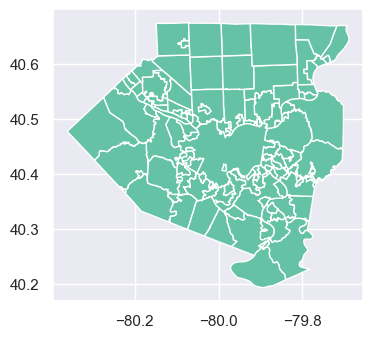

In [1663]:
muni_shp.plot(figsize=(4,4))

<Axes: >

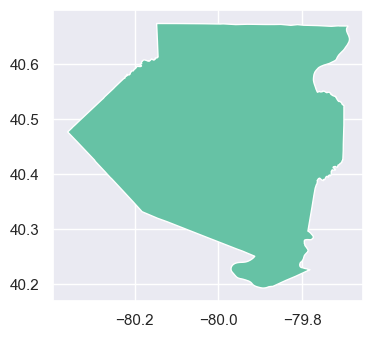

In [1664]:
cty_shp.plot(figsize=(4,4))

## Exploratory Visualizations

### Statistical Plots

In [1790]:
props_by_tax = pd.DataFrame(props.groupby(['Region', 'TAXCODE'])['FAIRMARKETTOTAL'].agg(['sum', 'count']))
props_by_tax.columns = ['VALUE', 'COUNT']
props_by_tax['pct_VALUE'] = props_by_tax['VALUE'] / props_by_tax.groupby('Region')['VALUE'].transform('sum')
props_by_tax['pct_COUNT'] = props_by_tax['COUNT'] / props_by_tax.groupby('Region')['COUNT'].transform('sum')
props_by_tax = props_by_tax.sort_values('Region', ascending=False)
props_by_tax = props_by_tax.reset_index()
props_by_tax

,Region,TAXCODE,VALUE,COUNT,pct_VALUE,pct_COUNT
0,Pittsburgh,E,11540247784,4508,0.192157,0.017471
1,Pittsburgh,T,48516093923,253521,0.807843,0.982529
2,County (excl. PGH),E,5094921668,3370,0.113816,0.014910
3,County (excl. PGH),T,39669744524,222657,0.886184,0.985090


In [ ]:
fig = px.bar(props_by_tax, 
             x='Region', y='VALUE', color='TAXCODE', custom_data=['COUNT', 'pct_VALUE', 'pct_COUNT'],
             category_orders={
                 'TAXCODE': ['T', 'E']
             },
             labels={
                'VALUE':'Prop Value',
                'TAXCODE':'Tax Code'
             }
)
fig.update_traces(
    hovertemplate = 
        '<b>%{data.name}</b>'
        + '<br>Prop Value: %{y:$.3s} (%{customdata[1]:.1%})'
        + '<br>Prop Count: %{customdata[0]:.3s} (%{customdata[2]:.1%})'
        + '<extra></extra>'
)
fig.update_layout(
    title=dict(
        text='Total Property Value by Taxable Status in <br>Allegheny County',
        subtitle=dict(
            text='<i>T = Taxable, E = Exempt</i>',
        ),
        yanchor='bottom',
        y=0.9,
    ),
    yaxis_title='% Share of Prop Value'
)
fig.update_layout(
    width=450,
    height=400,
    margin={'t':100},
    dragmode=False,
    hovermode='x unified'
)
# fig.write_image('imgs/propValByTaxTotal_bar.png', scale=2)
fig.write_html('html/fig1_bar_propValByTax.html')
fig.show(config={'displayModeBar':False})

In [1800]:
props_by_tax_exclClass = pd.DataFrame(props[props['CLASS'].isin(['HIGHER ED', 'COMMERCIAL'])]\
    .groupby(['Region', 'TAXCODE'])['FAIRMARKETTOTAL'].agg(['sum', 'count']))
props_by_tax_exclClass.columns = ['VALUE', 'COUNT']
props_by_tax_exclClass['pct_VALUE'] = props_by_tax_exclClass['VALUE'] / props_by_tax_exclClass.groupby('Region')['VALUE'].transform('sum')
props_by_tax_exclClass['pct_COUNT'] = props_by_tax_exclClass['COUNT'] / props_by_tax_exclClass.groupby('Region')['COUNT'].transform('sum')
props_by_tax_exclClass = props_by_tax_exclClass.sort_values('Region', ascending=False)
props_by_tax_exclClass = props_by_tax_exclClass.reset_index()
props_by_tax_exclClass

,Region,TAXCODE,VALUE,COUNT,pct_VALUE,pct_COUNT
0,Pittsburgh,E,5221139864,1397,0.259768,0.086727
1,Pittsburgh,T,14878083346,14711,0.740232,0.913273
2,County (excl. PGH),E,1345211948,1009,0.145330,0.085632
3,County (excl. PGH),T,7911066288,10774,0.854670,0.914368


In [ ]:
fig = px.bar(props_by_tax_exclClass, 
             x='Region', y='VALUE', color='TAXCODE', custom_data=['COUNT', 'pct_VALUE', 'pct_COUNT'],
             category_orders={
                 'TAXCODE': ['T', 'E']
             },
             labels={
                'VALUE':'Prop Value',
                'TAXCODE':'Tax Code'
             }
)
fig.update_traces(
    hovertemplate = 
        '<b>%{data.name}</b>'
        + '<br>Prop Value: %{y:$.3s} (%{customdata[1]:.1%})'
        + '<br>Prop Count: %{customdata[0]:.3s} (%{customdata[2]:.1%})'
        + '<extra></extra>'
)
fig.update_layout(
    title=dict(
        text='Commercial and Higher Ed Property Value by<br>Taxable Status in Allegheny County',
        subtitle=dict(
            text='<i>T = Taxable, E = Exempt</i>',
        ),
        yanchor='bottom',
        y=0.9,
    ),
    yaxis_title='% Share of Prop Value'
)
fig.update_layout(
    width=450,
    height=400,
    margin={'t':100},
    dragmode=False,
    hovermode='x unified'
)
# fig.write_image('imgs/propValByTaxTotal_bar.png', scale=2)
# fig.write_html('html/bar_propValByTax_exclClass.html')
fig.show(config={'displayModeBar':False})

In [1667]:
props_by_cityTax = props.groupby(['PROPERTYCITY', 'TAXCODE'])['FAIRMARKETTOTAL'].agg(['sum', 'count'])
props_by_cityTax.columns = ['VALUE', 'COUNT']
props_by_cityTax = props_by_cityTax.reset_index('TAXCODE')
props_by_cityTax['total_VALUE'] = props_by_cityTax.groupby('PROPERTYCITY')['VALUE'].sum()
props_by_cityTax['pct_VALUE'] = props_by_cityTax['VALUE'] / props_by_cityTax.groupby('PROPERTYCITY')['VALUE'].transform('sum')
props_by_cityTax['pct_COUNT'] = props_by_cityTax['COUNT'] / props_by_cityTax.groupby('PROPERTYCITY')['COUNT'].transform('sum')
props_by_cityTax = props_by_cityTax.reset_index()
props_by_cityTax = props_by_cityTax.sort_values('total_VALUE', ascending=False)
props_by_cityTax.head()

,PROPERTYCITY,TAXCODE,VALUE,COUNT,total_VALUE,pct_VALUE,pct_COUNT
114,PITTSBURGH,E,11540247784,4508,60056341707,0.192157,0.017471
115,PITTSBURGH,T,48516093923,253521,60056341707,0.807843,0.982529
36,CORAOPOLIS,T,3620060736,15992,4085487286,0.886078,0.984184
35,CORAOPOLIS,E,465426550,257,4085487286,0.113922,0.015816
158,WEXFORD,T,3259368568,8782,3631653768,0.897489,0.991308


In [ ]:
# fig = px.bar(props_by_cityTax[props_by_cityTax['PROPERTYCITY'].isin(props_by_cityTax['PROPERTYCITY'].unique()[:10])],
#     x='PROPERTYCITY', y='pct_VALUE', color='TAXCODE', custom_data=['pct_COUNT', 'VALUE', 'COUNT'],
#     category_orders={'TAXCODE':['T', 'E']},
#     labels={
#     'PROPERTYCITY':'City',
#     'FAIRMARKETTOTAL':'Prop Value',
#     'TAXCODE':'Tax Code'
#     }
# )
# fig.update_traces(
#     hovertemplate = 
#         '<b>%{data.name}</b>'
#         + '<br>Prop Value: %{customdata[1]:$,.3s} (%{y:.1%})'
#         + '<br>Prop Count: %{customdata[2]:,.3s} (%{customdata[0]:.1%})'
#         + '<extra></extra>'
# )
# fig.update_layout(
#     title=dict(
#         text='Property Value Share by Taxable Status in Top 10* Allegheny County Municipalities',
#         subtitle=dict(
#             text='<i>*Ordered by Total Value | T = Taxable, E = Exempt</i>',
#         ),
#         yanchor='bottom',
#         y=0.9
#     ),
#     yaxis_title='% Share of Prop Value'
# )
# fig.update_layout(
#     width=800,
#     height=400,
#     margin={'t':85},
#     dragmode=False,
#     hovermode='x unified'
# )
# # fig.write_image('imgs/propValByTaxCity_bar.png', scale=2)
# fig.show(config={'displayModeBar':False})

In [1818]:
props_by_classTax = props.groupby(['CLASS', 'TAXCODE'])['FAIRMARKETTOTAL'].agg(['sum', 'count'])
props_by_classTax.columns = ['VALUE', 'COUNT']
props_by_classTax = props_by_classTax.reset_index('TAXCODE')
props_by_classTax['total_VALUE'] = props_by_classTax.groupby('CLASS')['VALUE'].sum()
props_by_classTax['pct_VALUE'] = props_by_classTax['VALUE'] / props_by_classTax.groupby('CLASS')['VALUE'].transform('sum')
props_by_classTax['pct_COUNT'] = props_by_classTax['COUNT'] / props_by_classTax.groupby('CLASS')['COUNT'].transform('sum')
# props_by_classTax['pct_TAXCODEVAL'] = props_by_classTax['VALUE'] / props_by_classTax.groupby('TAXCODE')['VALUE'].transform('sum')
# props_by_classTax['pct_TAXCODECT'] = props_by_classTax['COUNT'] / props_by_classTax.groupby('TAXCODE')['COUNT'].transform('sum')
props_by_classTax = props_by_classTax.reset_index()
props_by_classTax = props_by_classTax.sort_values('total_VALUE', ascending=False)
props_by_classTax

,CLASS,TAXCODE,VALUE,COUNT,total_VALUE,pct_VALUE,pct_COUNT
8,RESIDENTIAL,E,321464800,2822,64487880456,0.004985,0.006242
9,RESIDENTIAL,T,64166415656,449274,64487880456,0.995015,0.993758
0,COMMERCIAL,E,3577050138,2147,25809530122,0.138594,0.077801
1,COMMERCIAL,T,22232479984,25449,25809530122,0.861406,0.922199
2,GOVERNMENT,E,7343705090,2399,7523444003,0.976109,0.925183
3,GOVERNMENT,T,179738913,194,7523444003,0.023891,0.074817
4,HIGHER ED,E,2989301674,259,3545971324,0.843013,0.877966
5,HIGHER ED,T,556669650,36,3545971324,0.156987,0.122034
6,OTHER,E,2403647750,251,3454181994,0.695866,0.170054
7,OTHER,T,1050534244,1225,3454181994,0.304134,0.829946


In [ ]:
# fig = px.bar(props_by_classTax,
#     x='CLASS', y='VALUE', color='TAXCODE', 
#     custom_data=['COUNT', 'pct_VALUE', 'pct_COUNT'],
#     labels={
#         'CLASS': 'Use Class',
#         'TAXCODE': 'Tax Code'
#     },
#     category_orders={
#         'CLASS':['HIGHER ED', 'GOVERNMENT', 'COMMERCIAL', 'RESIDENTIAL', 'OTHER'],
#         'TAXCODE':['T', 'E'],
#     },
# )
# fig.update_traces(
#     hovertemplate = 
#         '<b>%{data.name}</b>'
#         + '<br>Prop Value: %{y:$.3s} (%{customdata[1]:.1%})'
#         + '<br>Prop Count: %{customdata[0]:.3s} (%{customdata[2]:.1%})'
#         # + '<br>Share of Tax Code: %{customdata[3]:.1%}'
#         # + '<br>Share of Total Ct: %{customdata[4]:.1%}'
#         + '<extra></extra>'
# )
# fig.update_layout(
#     title=dict(
#         text='Aggregate Property Value by Use Class and Taxable Status in Allegheny County',
#         subtitle=dict(
#             text='<i>T = Taxable, E = Exempt</i>',
#         ),
#         yanchor='bottom',
#         y=0.9
#     ),
#     yaxis_title='Total Prop Value'
# )
# fig.update_layout(
#     width=800,
#     height=400,
#     margin={'t':85},
#     dragmode=False,
#     hovermode='x unified',
# )
# # fig.write_image('imgs/propValByUseTax_bar.png', scale=2)
# fig.write_html('html/bar_propValByUseTax.html')
# fig.show(config={'displayModeBar':False})

In [1843]:
props_by_classTax_region = props.groupby(['Region', 'CLASS', 'TAXCODE'])['FAIRMARKETTOTAL'].agg(['sum', 'count'])
props_by_classTax_region.columns = ['VALUE', 'COUNT']
props_by_classTax_region = props_by_classTax_region.reset_index('TAXCODE')
props_by_classTax_region['total_VALUE'] = props_by_classTax_region.groupby('CLASS')['VALUE'].sum()
props_by_classTax_region['pct_VALUE'] = props_by_classTax_region['VALUE'] / props_by_classTax_region.groupby(['Region', 'CLASS'])['VALUE'].transform('sum')
props_by_classTax_region['pct_COUNT'] = props_by_classTax_region['COUNT'] / props_by_classTax_region.groupby(['Region', 'CLASS'])['COUNT'].transform('sum')
props_by_classTax_region = props_by_classTax_region.reset_index('CLASS')
props_by_classTax_region = props_by_classTax_region.sort_values('total_VALUE', ascending=False)

In [ ]:
fig = px.bar(props_by_classTax_region.loc['County (excl. PGH)'],
    x='CLASS', y='VALUE', color='TAXCODE', 
    custom_data=['COUNT', 'pct_VALUE', 'pct_COUNT'],
    labels={
        'CLASS': 'Use Class',
        'TAXCODE': 'Tax Code'
    },
    category_orders={
        'CLASS':['HIGHER ED', 'GOVERNMENT', 'COMMERCIAL', 'RESIDENTIAL', 'OTHER'],
        'TAXCODE':['T', 'E'],
    },
)
fig.update_traces(
    hovertemplate = 
        '<b>%{data.name}</b>'
        + '<br>Prop Value: %{y:$.3s} (%{customdata[1]:.1%})'
        + '<br>Prop Count: %{customdata[0]:.3s} (%{customdata[2]:.1%})'
        + '<extra></extra>'
)
fig.update_layout(
    title=dict(
        text='Aggregate Property Value by Use Class and Taxable Status in Allegheny County <br>(excl. Pittsburgh)',
        subtitle=dict(
            text='<i>T = Taxable, E = Exempt</i>',
        ),
        yanchor='bottom',
        y=0.9
    ),
    yaxis_title='Total Prop Value'
)
fig.update_layout(
    width=800,
    height=400,
    margin={'t':105},
    dragmode=False,
    hovermode='x unified',
)
# fig.write_image('imgs/propValByUseTax_bar.png', scale=2)
fig.write_html('html/fig2a_bar_propValByUseTax_cty.html')
fig.show(config={'displayModeBar':False})

In [ ]:
fig = px.bar(props_by_classTax_region.loc['Pittsburgh'],
    x='CLASS', y='VALUE', color='TAXCODE', 
    custom_data=['COUNT', 'pct_VALUE', 'pct_COUNT'],
    labels={
        'CLASS': 'Use Class',
        'TAXCODE': 'Tax Code'
    },
    category_orders={
        'CLASS':['HIGHER ED', 'GOVERNMENT', 'COMMERCIAL', 'RESIDENTIAL', 'OTHER'],
        'TAXCODE':['T', 'E'],
    },
)
fig.update_traces(
    hovertemplate = 
        '<b>%{data.name}</b>'
        + '<br>Prop Value: %{y:$.3s} (%{customdata[1]:.1%})'
        + '<br>Prop Count: %{customdata[0]:.3s} (%{customdata[2]:.1%})'
        + '<extra></extra>'
)
fig.update_layout(
    title=dict(
        text='Aggregate Property Value by Use Class and Taxable Status in Pittsburgh',
        subtitle=dict(
            text='<i>T = Taxable, E = Exempt</i>',
        ),
        yanchor='bottom',
        y=0.9
    ),
    yaxis_title='Total Prop Value'
)
fig.update_layout(
    width=800,
    height=400,
    margin={'t':85},
    dragmode=False,
    hovermode='x unified',
)
# fig.write_image('imgs/propValByUseTax_bar.png', scale=2)
fig.write_html('html/fig2b_bar_propValByUseTax_pgh.html')
fig.show(config={'displayModeBar':False})

In [1699]:
# props.groupby(['CLASS', 'TAXCODE'])
props_by_cityClassTax = props.groupby(['PROPERTYCITY', 'CLASS', 'TAXCODE'])['FAIRMARKETTOTAL'].agg(['sum', 'count'])
props_by_cityClassTax.columns = ['VALUE', 'COUNT']
props_by_cityClassTax = props_by_cityClassTax.reset_index('TAXCODE')
props_by_cityClassTax['total_VALUE'] = props_by_cityClassTax.groupby(['PROPERTYCITY', 'CLASS'])['VALUE'].sum()
props_by_cityClassTax['pct_VALUE'] = props_by_cityClassTax['VALUE'] / props_by_cityClassTax.groupby(['PROPERTYCITY', 'CLASS'])['VALUE'].transform('sum')
props_by_cityClassTax['pct_COUNT'] = props_by_cityClassTax['COUNT'] / props_by_cityClassTax.groupby(['PROPERTYCITY', 'CLASS'])['COUNT'].transform('sum')
props_by_cityClassTax = props_by_cityClassTax.reset_index()
props_by_cityClassTax = props_by_cityClassTax.sort_values('total_VALUE', ascending=False)
props_by_cityClassTax.head()

,PROPERTYCITY,CLASS,TAXCODE,VALUE,COUNT,total_VALUE,pct_VALUE,pct_COUNT
361,PITTSBURGH,RESIDENTIAL,E,161898500,1688,33195270366,0.004877,0.007031
362,PITTSBURGH,RESIDENTIAL,T,33033371866,238377,33195270366,0.995123,0.992969
353,PITTSBURGH,COMMERCIAL,E,2581379990,1162,16931593086,0.152459,0.073349
354,PITTSBURGH,COMMERCIAL,T,14350213096,14680,16931593086,0.847541,0.926651
355,PITTSBURGH,GOVERNMENT,E,4451501070,1261,4594026413,0.968976,0.925165


In [1795]:
props_by_cityClassTax[~props_by_cityClassTax['CLASS'].isin(['RESIDENTIAL', 'GOVERNMENT'])]

,PROPERTYCITY,CLASS,TAXCODE,VALUE,COUNT,total_VALUE,pct_VALUE,pct_COUNT
353,PITTSBURGH,COMMERCIAL,E,2581379990,1162,16931593086,0.152459,0.073349
354,PITTSBURGH,COMMERCIAL,T,14350213096,14680,16931593086,0.847541,0.926651
358,PITTSBURGH,HIGHER ED,T,527870250,31,3167630124,0.166645,0.116541
357,PITTSBURGH,HIGHER ED,E,2639759874,235,3167630124,0.833355,0.883459
360,PITTSBURGH,OTHER,T,462113368,331,2167821718,0.213169,0.671400
...,...,...,...,...,...,...,...,...
368,PRESTO,OTHER,T,12600,1,12600,1.000000,1.000000
136,CUDDY,OTHER,T,6200,1,6200,1.000000,1.000000
350,PITCAIRN,OTHER,T,6100,2,6100,1.000000,1.000000
244,LEETSDALE,OTHER,T,2700,2,2700,1.000000,1.000000


In [ ]:
fig = px.bar(props_by_classTax,
    x='TAXCODE', y='VALUE', color='CLASS', 
    custom_data=['COUNT', 'pct_VALUE', 'pct_COUNT'],
    labels={
        'CLASS': 'Use Class',
        'TAXCODE': 'Tax Code'
    },
    category_orders={
        'CLASS':['HIGHER ED', 'GOVERNMENT', 'COMMERCIAL', 'RESIDENTIAL', 'OTHER'],
        'TAXCODE':['T', 'E'],
    },
    color_discrete_sequence=np.append(px.colors.qualitative.Plotly[:4], 'rgb(150, 150, 150)'),
)
fig.update_traces(
    hovertemplate = 
        '<b>%{data.name}</b>'
        + '<br>Prop Value: %{y:$.3s} (%{customdata[1]:.1%})'
        + '<br>Prop Count: %{customdata[0]:.3s} (%{customdata[2]:.1%})'
        + '<extra></extra>'
)
fig.update_layout(
    title=dict(
        text='Property Value by Use Class and Taxable Status in Allegheny County',
        subtitle=dict(
            text='<i>T = Taxable, E = Exempt</i>',
        ),
        yanchor='bottom',
        y=0.9
    ),
    yaxis_title='Total Prop Value'
)
fig.update_layout(
    width=700,
    height=400,
    margin={'t':85},
    dragmode=False,
    hovermode='x unified',
)
# fig.write_image('imgs/propValByTaxUse_bar.png', scale=2)
fig.write_html('html/props_bar_valByTaxUse_cty.html')
fig.show(config={'displayModeBar':False})

In [ ]:
fig = px.bar(props_by_cityClassTax[props_by_cityClassTax['PROPERTYCITY'] == 'PITTSBURGH'],
    x='TAXCODE', y='VALUE', color='CLASS', 
    custom_data=['COUNT', 'pct_VALUE', 'pct_COUNT'],
    labels={
        'CLASS': 'Use Class',
        'TAXCODE': 'Tax Code'
    },
    category_orders={
        'CLASS':['HIGHER ED', 'GOVERNMENT', 'COMMERCIAL', 'RESIDENTIAL', 'OTHER'],
        'TAXCODE':['T', 'E'],
    },
    color_discrete_sequence=np.append(px.colors.qualitative.Plotly[:4], 'rgb(150, 150, 150)'),
)
fig.update_traces(
    hovertemplate = 
        '<b>%{data.name}</b>'
        + '<br>Prop Value: %{y:$.3s} (%{customdata[1]:.1%})'
        + '<br>Prop Count: %{customdata[0]:.3s} (%{customdata[2]:.1%})'
        + '<extra></extra>'
)
fig.update_layout(
    title=dict(
        text='Property Value by Use Class and Taxable Status in Pittsburgh',
        subtitle=dict(
            text='<i>T = Taxable, E = Exempt</i>',
        ),
        yanchor='bottom',
        y=0.9
    ),
    yaxis_title='Total Prop Value'
)
fig.update_layout(
    width=700,
    height=400,
    margin={'t':85},
    dragmode=False,
    hovermode='x unified',
)
# fig.write_image('imgs/propValByTaxUse_bar.png', scale=2)
fig.write_html('html/props_bar_valByUseTax_pgh.html')
fig.show(config={'displayModeBar':False})

In [ ]:
fig = px.histogram(props, x='log_FAIRMARKET', color='TAXCODE', hover_name='PROP_CLEANADDR',
                   histnorm='probability', nbins=50, opacity=0.5, barmode='overlay')
fig.update_layout(
    hovermode='x unified',
    width=800,
    height=400
)
fig.show()

In [ ]:
fig = px.histogram(props[props['Region'] == 'Pittsburgh'], x='log_FAIRMARKET', color='TAXCODE', hover_name='PROP_CLEANADDR',
                   histnorm='probability', nbins=50, opacity=0.5, barmode='overlay')
fig.update_layout(
    hovermode='x unified',
    width=800,
    height=400
)
fig.show()

In [ ]:
fig = px.violin(props, x='log_FAIRMARKET', color='TAXCODE', hover_name='PROP_CLEANADDR',
                # box=True
)
fig.update_traces(
    box=dict(
        visible=True,
        line_width=2,
        width=0.15
    ),
    hoveron='violins+points',
)
fig.update_layout(
    width=800,
    height=500
)
fig.show()

In [ ]:
fig = px.violin(props[props['Region'] == 'Pittsburgh'], x='log_FAIRMARKET', color='TAXCODE', hover_name='PROP_CLEANADDR',
                # box=True
)
fig.update_traces(
    box=dict(
        visible=True,
        line_width=2,
        width=0.15
    ),
    hoveron='violins+points',
)
fig.update_layout(
    width=800,
    height=500
)
fig.show()

In [1674]:
# fig = px.pie(props.groupby('TAXCODE')['FAIRMARKETTOTAL'].sum().reset_index(), 
#              names='TAXCODE', values='FAIRMARKETTOTAL',
#              hole=0.3,
#              )
# fig.update_traces(
#     hovertemplate="%{label}<br>%{value:$.3s}<extra></extra>"
# )
# fig.update_layout(
#     legend=dict(
#         orientation='h',
#         xanchor='center',
#         x=0.5,
#         yanchor='bottom',
#         y=1,
#     )
# )
# fig.update_layout(
#     width=400,
#     height=400
# )
# fig.show()

In [1675]:
# # only top 10 owners (sorted by total prop count)
# fig = px.bar(owners_by_tax.reset_index('TAXCODE').loc[owners.sort_values('PROP_COUNT', ascending=False).index[:10]], 
#              x='PROP_COUNT', y='OWNER_CLEANADDR', color='TAXCODE', 
#              hover_name='OWNER_CLEANADDR', hover_data = 'PROP_VALUE',
#              category_orders={'TAXCODE': ['', 'E', 'T']},
#        )
# fig.update_layout(
#        yaxis=dict(
#               # categoryorder='category ascending',
#               autorange='reversed',
#        )
# )
# fig.update_layout(
#        width=800,
#        height=500
# )
# fig.show()

In [1676]:
# fig = px.bar(owners_by_tax.reset_index('TAXCODE').loc[owners.sort_values('PROP_VALUE', ascending=False).index[:10]], 
#              x='PROP_VALUE', y='OWNER_CLEANADDR', color='TAXCODE', 
#              hover_name='OWNER_CLEANADDR', hover_data = ['PROP_COUNT'],
#              category_orders={'TAXCODE': ['', 'E', 'T']},
#        )
# fig.update_layout(
#        yaxis=dict(
#               # categoryorder='category ascending',
#               autorange='reversed',
#        )
# )
# fig.update_layout(
#        width=800,
#        height=500
# )
# fig.show()

In [1677]:
# fig = px.bar(owners.sort_values('PROP_COUNT', ascending=False).head(20), 
#              x='PROP_COUNT', y='OWNER_CLEANADDR', color='pct_CT_EXEMPT', 
#              color_continuous_scale='Redor', range_color=0, orientation='h', height=500,
#              hover_name='OWNER_CLEANADDR',
#        )
# fig.update_layout(
#        yaxis=dict(
#               # categoryorder='array',
#               autorange='reversed',
#        )
# )
# fig.show()

In [1678]:
# fig = px.bar(owners.sort_values('PROP_COUNT', ascending=False).head(20), 
#              x='PROP_COUNT', y='OWNER_CLEANADDR', color='PROP_VALUE', 
#               color_continuous_scale='blugrn', range_color=0, orientation='h', height=500,
#               hover_name='OWNER_CLEANADDR',
#               # hover_data='PROP_COUNT'
#        )
# fig.update_layout(
#        yaxis=dict(
#               # categoryorder='array',
#               autorange='reversed',
#        )
# )
# fig.show()

### Maps

In [1679]:
# fig = px.scatter_map(g_owners, lat='lat', lon='lon', size='PROP_COUNT',
#                      hover_name='OWNER_CLEANADDR')
# fig.update_traces(
#     marker=dict(
#         sizemin=1,
#         sizeref=1.5,
#     )
# )
# fig.update_layout(
#     map=dict(
#         center=dict(
#             lon=cty_center.x,
#             lat=cty_center.y
#         ),
#         zoom=9,
#         style='carto-positron'
#     )
# )
# fig.update_layout(
#     height=600,
#     width=800
# )
# fig.update_layout(margin={'r':0,'t':0,'l':0,'b':0})
# fig.show()

In [1680]:
# fig = px.scatter_map(g_owners.sort_values('PROP_COUNT'), 
#                      lat='lat', lon='lon', size='PROP_COUNT', color='pct_CT_EXEMPT', 
#                      hover_name='OWNER_CLEANADDR',
#                      color_continuous_scale='Redor')
# fig.update_traces(
#     marker=dict(
#         sizeref=1,
#     )
# )
# fig.update_layout(
#     map=dict(
#         center=dict(
#             lon=cty_center.x,
#             lat=cty_center.y
#         ),
#         zoom=9,
#         style='carto-positron'
#     )
# )
# fig.update_coloraxes(
#     colorbar=dict(
#         xanchor='left',
#         x=0.01,
#         yanchor='top',
#         y=0.99,
#         title_font_shadow='auto',
#         tickfont_shadow='auto',
#     )
# )
# fig.update_layout(
#     height=600,
#     width=800
# )
# fig.update_layout(margin={'r':0,'t':0,'l':0,'b':0})
# fig.show()

In [ ]:
fig = px.scatter_map(g_owners.sort_values('PROP_VALUE'), 
    lat='lat', lon='lon', size='PROP_VALUE', color='pct_VAL_EXEMPT',
    labels={
        'pct_VAL_EXEMPT': 'Exempt Value'
    },
    custom_data=['OWNER_CLEANADDR', 'OWNER_CITY', 'OWNER_STATE', 'PROP_VALUE', 'PROP_COUNT', 'pct_VAL_EXEMPT', 'pct_CT_EXEMPT'],
    color_continuous_scale='Redor'
)
fig.update_traces(
    marker=dict(
        sizeref=g_owners['PROP_VALUE'].median(),
    )
)
fig.update_traces(
    hovertemplate=
        '<b>%{customdata[0]}</b>'
        # + '<br>%{customdata[1]} %{customdata[2]}'
        + '<br>Owned Value: %{customdata[3]:$.3s}'
        + '<br>Owned Props: %{customdata[4]:,}'
        + '<br>Pct Value Exempt: %{customdata[5]:.1%}'
        + '<br>Pct Props Exempt: %{customdata[6]:.1%}'
)
fig.update_layout(
    map=dict(
        center=dict(
            lon=cty_center.x,
            lat=cty_center.y
        ),
        zoom=9,
        style='carto-positron'
    )
)
fig.update_layout(
    title=dict(
        text='Property Owners in Allegheny County by Total and Tax-Exempt Value',
        subtitle=dict(
            text='<i>Size represents total owned value<br>Top 1k owners by property count are displayed</i>'
        ),
        yanchor='bottom',
        y=0.96,
        xanchor='left',
        x=0.03
    ),
)
fig.update_coloraxes(
    colorbar=dict(
        xanchor='left',
        x=0.01,
        yanchor='top',
        y=0.99,
        title_font_shadow='auto',
        tickfont_shadow='auto',
        tickformat='.0%'
    )
)
fig.update_layout(
    height=700,
    width=850,
    margin={'r':10,'t':85,'l':10,'b':10}
)
fig.write_html('html/fig5_scatterMap_ownerValByTax.html')
fig.show()

In [2069]:
top_owners = g_owners[['OWNER_CLEANADDR', 'PROP_COUNT', 'PROP_VALUE', 'pct_VAL_EXEMPT', 'pct_CT_EXEMPT']]\
    .sort_values('PROP_VALUE', ascending=False).head(25)

In [2070]:
# manually searched
top_owners.loc[:, 'INFERRED_IDENTITY'] = top_owners['OWNER_CLEANADDR'].map(
    {
        '600 GRANT ST FL 60 PITTSBURGH PA': 'UPMC',
        '3525 FORBES AVE PITTSBURGH PA': 'University of Pittsburgh',
        '414 GRANT ST RM 200 PITTSBURGH PA': 'City of Pittsburgh',
        '171 10TH ST FL 2 PITTSBURGH PA': 'Sports & Exhibition Authority',
        '542 FORBES AVE RM 347 PITTSBURGH PA': 'Office of Property Assessment',
        '120 5TH AVE STE 2900 PITTSBURGH PA': 'Allegheny Health Network',
        '10 S HOWARD ST FL 7 BALTIMORE MD': '[UNKNOWN (Baltimore MD)]',
        '341 S BELLEFIELD AVE PITTSBURGH PA': 'Pittsburgh Public Schools',
        '600 FORBES AVE STE 505 PITTSBURGH PA': 'Duquesne University',
        '412 BLVD OF THE ALLIES FL 7 PITTSBURGH PA': 'Pittsburgh Housing Authority',
        '5500 WALNUT ST STE 300 PITTSBURGH PA': 'Walnut Capital Management',
        '1000 CONTINENTAL DR STE 550 KING OF PRUSSIA PA': 'Ryan Law',
        '5000 FORBES AVE PITTSBURGH PA': 'Carnegie Mellon University',
        'PO BOX 850 AURORA OH': '[UNKNOWN (Aurora OH)]',
        '310 SEVEN FIELDS BLVD STE 350 MARS PA': 'AR Building Company',
        '4400 FORBES AVE PITTSBURGH PA': 'Carnegie Library and Museums',
        'PO BOX 27497 GREENSBORO NC': 'USPS',
        '800 ALLEGHENY AVE PITTSBURGH PA': 'CCAC',
        '317 E CARSON ST STE 146 PITTSBURGH PA': 'McKnight Realty Partners',
        '2500 ELDO RD STE 1 MONROEVILLE PA': 'Sampson Morris Group',
        '300 LIBERTY AVE PITTSBURGH PA': 'Apartments at River View',
        '301 CHARTIERS AVE MC KEES ROCKS PA': 'Allegheny County Housing Authority',
        '12245 FRANKSTOWN RD PITTSBURGH PA': 'Penn Hills Township',
        '1251 WATERFRONT PL STE 201 PITTSBURGH PA': 'The Buncher Company',
        '345 6TH AVE PITTSBURGH PA': 'Pittsburgh Regional Transit'
    }
)

In [2071]:
top_owners['INFERRED_IDENTITY'].to_list()

['UPMC',
 'University of Pittsburgh',
 'City of Pittsburgh',
 'Sports & Exhibition Authority',
 'Office of Property Assessment',
 'Allegheny Health Network',
 '[UNKNOWN (Baltimore MD)]',
 'Pittsburgh Public Schools',
 'Duquesne University',
 'Pittsburgh Housing Authority',
 'Walnut Capital Management',
 'Ryan Law',
 'Carnegie Mellon University',
 '[UNKNOWN (Aurora OH)]',
 'AR Building Company',
 'Carnegie Library and Museums',
 'USPS',
 'CCAC',
 'McKnight Realty Partners',
 'Sampson Morris Group',
 'Apartments at River View',
 'Allegheny County Housing Authority',
 'Penn Hills Township',
 'The Buncher Company',
 'Pittsburgh Regional Transit']

In [2098]:
top_owners.loc[:, 'OWNER_CLASS'] = top_owners['INFERRED_IDENTITY'].map(
    {
        'UPMC': 'Healthcare',
        'University of Pittsburgh': 'University',
        'City of Pittsburgh': 'Government/Public',
        'Sports & Exhibition Authority': 'Government/Public',
        'Office of Property Assessment': 'Government/Public',
        'Allegheny Health Network': 'Healthcare',
        '[UNKNOWN (Baltimore MD)]': 'other/unknown',
        'Pittsburgh Public Schools': 'Government/Public',
        'Duquesne University': 'University',
        'Pittsburgh Housing Authority': 'Government/Public',
        'Walnut Capital Management': 'Real Estate',
        'Ryan Law': 'other/unknown',
        'Carnegie Mellon University': 'University',
        '[UNKNOWN (Aurora OH)]': 'other/unknown',
        'AR Building Company': 'Real Estate',
        'Carnegie Library and Museums': 'Government/Public',
        'USPS': 'Government/Public',
        'CCAC': 'Government/Public',
        'McKnight Realty Partners': 'Real Estate',
        'Sampson Morris Group': 'Real Estate',
        'Apartments at River View': 'Real Estate',
        'Allegheny County Housing Authority': 'Government/Public',
        'Penn Hills Township': 'Government/Public',
        'The Buncher Company': 'Real Estate',
        'Pittsburgh Regional Transit': 'Government/Public'
    }
)

In [2099]:
top_owners

,OWNER_CLEANADDR,PROP_COUNT,PROP_VALUE,pct_VAL_EXEMPT,pct_CT_EXEMPT,INFERRED_IDENTITY,OWNER_CLASS
OWNER_ID,,,,,,,
855683786454,600 GRANT ST FL 60 PITTSBURGH PA,94,1689692546,0.737940,0.489362,UPMC,Healthcare
953461566823,3525 FORBES AVE PITTSBURGH PA,98,1380770200,0.694529,0.704082,University of Pittsburgh,University
629560013250,414 GRANT ST RM 200 PITTSBURGH PA,819,1263804800,0.974664,0.935287,City of Pittsburgh,Government/Public
839276994120,171 10TH ST FL 2 PITTSBURGH PA,21,802436100,1.000000,1.000000,Sports & Exhibition Authority,Government/Public
421301134122,542 FORBES AVE RM 347 PITTSBURGH PA,83,620998900,0.999876,0.987952,Office of Property Assessment,Government/Public
437743319789,120 5TH AVE STE 2900 PITTSBURGH PA,34,579910840,0.383985,0.235294,Allegheny Health Network,Healthcare
919968469741,10 S HOWARD ST FL 7 BALTIMORE MD,23,514614600,1.000000,1.000000,[UNKNOWN (Baltimore MD)],other/unknown
644498668142,341 S BELLEFIELD AVE PITTSBURGH PA,70,514217500,1.000000,1.000000,Pittsburgh Public Schools,Government/Public
709544648036,600 FORBES AVE STE 505 PITTSBURGH PA,40,466969900,0.795690,0.825000,Duquesne University,University


In [2109]:
fig = px.bar(top_owners.sort_values('PROP_VALUE'),
    y='INFERRED_IDENTITY', x='PROP_VALUE', color='pct_VAL_EXEMPT', 
    custom_data=['OWNER_CLEANADDR', 'OWNER_CLASS', 'pct_VAL_EXEMPT', 'PROP_COUNT', 'pct_CT_EXEMPT'],
    labels={
        'INFERRED_IDENTITY': 'Inferred Identity',
        'PROP_VALUE': 'Total Property Value',
        'pct_VAL_EXEMPT': 'Pct Exempt',
    },
    color_continuous_scale='Redor'
)
fig.update_traces(
    hovertemplate = 
        '<b>%{y}</b>'
        + '<br>%{customdata[0]}'
        + '<br>Category: %{customdata[1]}'
        + '<br>Owned Value: %{x:$.3s} (%{customdata[2]:.1%} exempt)'
        + '<br>Props Owned: %{customdata[3]:,} (%{customdata[4]:.1%} exempt)'
        + '<extra></extra>'
)
fig.update_layout(
    title=dict(
        text='Top 25 Property Owners in Allegheny County by Owned Value',
        subtitle=dict(
            text='<i>Shading represents share of property value that is tax-exempt',
        ),
        yanchor='bottom',
        y=0.9
    ),
)
fig.update_coloraxes(
    colorbar=dict(
        tickformat='.0%'
    )
)
fig.update_layout(
    width=1000,
    height=700,
    margin={'t':105},
    dragmode=False,
    # hovermode='y unified',
)
# fig.write_image('imgs/propValByUseTax_bar.png', scale=2)
fig.write_html('html/fig6a_bar_ownersByVal.html')
fig.show(config={'displayModeBar':False})

In [2127]:
fig = px.scatter(top_owners.sort_values('PROP_VALUE'),
    x='PROP_VALUE', y='pct_VAL_EXEMPT', color='OWNER_CLASS',
    custom_data=['INFERRED_IDENTITY', 'OWNER_CLEANADDR', 'OWNER_CLASS', 'pct_VAL_EXEMPT', 'PROP_COUNT', 'pct_CT_EXEMPT'],
    labels={
        'OWNER_CLASS': 'Owner Category',
        'PROP_VALUE': 'Total Property Value',
        'pct_VAL_EXEMPT': 'Pct of Value Exempt',
    },
    category_orders={
        'OWNER_CLASS': ['Government/Public', 'Healthcare', 'University', 'Real Estate', 'other/unknown']
    },
    color_discrete_sequence=np.append(px.colors.qualitative.Plotly[:4], 'rgb(150, 150, 150)'),
    
)
fig.update_traces(
    marker=dict(
        size=10,
        opacity=0.7
    )
)
fig.update_traces(
    hovertemplate = 
        '<b>%{customdata[0]}</b>'
        + '<br>%{customdata[1]}'
        + '<br>Category: %{customdata[2]}'
        + '<br>Owned Value: %{x:$.3s} (%{customdata[3]:.1%} exempt)'
        + '<br>Props Owned: %{customdata[4]:,} (%{customdata[5]:.1%} exempt)'
        + '<extra></extra>'
)
fig.update_layout(
    title=dict(
        text='Total Value and Exempt Share of Top 25* Property Owners in Allegheny County',
        subtitle=dict(
            text='<i>*By owned value',
        ),
        yanchor='bottom',
        y=0.9
    ),
)
fig.update_layout(
    width=800,
    height=500,
    margin={'t':105},
    dragmode=False,
)
# fig.write_image('imgs/propValByUseTax_bar.png', scale=2)
fig.write_html('html/fig6b_scatter_ownersByValTax.html')
fig.show(config={'displayModeBar':False})

In [2117]:
fig = px.bar(top_owners.sort_values('PROP_VALUE'),
    y='OWNER_CLASS', x='PROP_VALUE', color='pct_VAL_EXEMPT', 
    custom_data=['INFERRED_IDENTITY', 'OWNER_CLEANADDR', 'pct_VAL_EXEMPT', 'PROP_COUNT', 'pct_CT_EXEMPT'],
    labels={
        'OWNER_CLASS': 'Owner Category',
        'PROP_VALUE': 'Total Property Value',
        'pct_VAL_EXEMPT': 'Pct Exempt',
    },
    color_continuous_scale='Redor'
)
fig.update_traces(
    hovertemplate = 
        '<b>%{customdata[0]}</b>'
        + '<br>%{customdata[1]}'
        + '<br>Owned Value: %{x:$.3s} (%{customdata[2]:.1%} exempt)'
        + '<br>Props Owned: %{customdata[3]:,} (%{customdata[4]:.1%} exempt)'
        + '<extra></extra>'
)
fig.update_yaxes(
    categoryorder='total ascending'
)
fig.update_layout(
    title=dict(
        text='Top 25 Property Owners in Allegheny County by Owned Value',
        subtitle=dict(
            text='<i>Shading represents share of property value that is tax-exempt',
        ),
        yanchor='bottom',
        y=0.9
    ),
)
fig.update_coloraxes(
    colorbar=dict(
        tickformat='.0%'
    )
)
fig.update_layout(
    width=1000,
    height=700,
    margin={'t':105},
    dragmode=False,
)
# fig.write_image('imgs/propValByUseTax_bar.png', scale=2)
# fig.write_html('html/fig6_bar_ownersByVal.html')
fig.show(config={'displayModeBar':False})

In [2035]:
# fig = px.scatter_map(g_props.sort_values('FAIRMARKETTOTAL', ascending=False).head(10000),
#                      lat='lat', lon='lon', size='FAIRMARKETTOTAL', color='TAXCODE',
#                      custom_data=['PROP_CLEANADDR', 'PROPERTYCITY', 'FAIRMARKETTOTAL', 'CLASS', 'USEDESC'],
#                      category_orders={'TAXCODE': ['T', 'E']},
#                      labels={
#                          'TAXCODE':'Tax Code',
#                      }
# )
# fig.update_traces(
#     hovertemplate=
#         '<b>%{customdata[0]}</b>'
#         + '<br>%{customdata[1]}'
#         + '<br>Prop Value: %{customdata[2]:$.3s}'
#         + '<br>Use Class: %{customdata[3]}'
#         + '<br>Use Desc: %{customdata[4]}'
# )
# fig.update_layout(
#     map=dict(
#         center=dict(
#             lon=cty_center.x,
#             lat=cty_center.y
#         ),
#         zoom=9.5,
#         bounds=dict(
#             west=cty_shp.total_bounds[0] * 1.001,
#             south=cty_shp.total_bounds[1] * 0.999,
#             east=cty_shp.total_bounds[2] * 0.999,
#             north=cty_shp.total_bounds[3] * 1.001,
#         ),
#         style='carto-positron',
#     )
# )
# fig.update_layout(
#     title=dict(
#         text='Properties in Allegheny County by Value and Taxable Status',
#         subtitle=dict(
#             text='<i>Size represents Fair Market Value | T = Taxable, E = Exempt<br>Top 10k properties by value are displayed</i>'
#         ),
#         yanchor='bottom',
#         y=0.96,
#         xanchor='left',
#         x=0.03
#     ),
# )
# fig.update_layout(
#     legend=dict(
#         orientation='v',
#         xanchor='left',
#         x=0.01,
#         yanchor='top',
#         y=0.99,
#         borderwidth=1,
#         bordercolor='rgba(1, 1, 1, 0.1)',
#     )
# )
# fig.update_layout(
#     height=700,
#     width=850,
#     margin={'r':10,'t':85,'l':10,'b':10}
# )
# # fig.write_image('imgs/propValByTax_scatter.png', scale=5)
# fig.write_html('html/fig4_scatterMap_propValByTax.html')
# fig.show()

In [ ]:
# commercial and higher ed only
fig = px.scatter_map(g_props[g_props['CLASS'].isin(['COMMERCIAL', 'HIGHER ED'])]\
    .sort_values('FAIRMARKETTOTAL', ascending=False).head(10000),
    lat='lat', lon='lon', size='FAIRMARKETTOTAL', color='TAXCODE',
    custom_data=['PROP_CLEANADDR', 'PROPERTYCITY', 'FAIRMARKETTOTAL', 'CLASS', 'USEDESC'],
    category_orders={'TAXCODE': ['T', 'E']},
    labels={
        'TAXCODE':'Tax Code',
    }
)
fig.update_traces(
    hovertemplate=
        '<b>%{customdata[0]}</b>'
        + '<br>%{customdata[1]}'
        + '<br>Prop Value: %{customdata[2]:$.3s}'
        + '<br>Use Class: %{customdata[3]}'
        + '<br>Use Desc: %{customdata[4]}'
)
fig.update_layout(
    map=dict(
        center=dict(
            lon=cty_center.x,
            lat=cty_center.y
        ),
        zoom=9.5,
        bounds=dict(
            west=cty_shp.total_bounds[0] * 1.001,
            south=cty_shp.total_bounds[1] * 0.999,
            east=cty_shp.total_bounds[2] * 0.999,
            north=cty_shp.total_bounds[3] * 1.001,
        ),
        style='carto-positron',
    )
)
fig.update_layout(
    title=dict(
        text='Commercial and Higher Ed Properties in Allegheny County<br>by Value and Taxable Status',
        subtitle=dict(
            text='<i>Size represents Fair Market Value | T = Taxable, E = Exempt<br>Top 10k properties by value are displayed</i>'
        ),
        yanchor='bottom',
        y=0.96,
        xanchor='left',
        x=0.03
    ),
)
fig.update_layout(
    legend=dict(
        orientation='v',
        xanchor='left',
        x=0.01,
        yanchor='top',
        y=0.99,
        borderwidth=1,
        bordercolor='rgba(1, 1, 1, 0.1)',
    )
)
fig.update_layout(
    height=700,
    width=850,
    margin={'r':10,'t':100,'l':10,'b':10}
)
# fig.write_image('imgs/propValByTax_scatter.png', scale=5)
fig.write_html('html/fig4_scatterMap_propValByTax.html')
fig.show()

In [2027]:
g_props.loc[
    (g_props['CLASS'].isin(['COMMERCIAL', 'HIGHER ED'])) & (g_props['PROPERTYCITY'] != 'PITTSBURGH') & (g_props['TAXCODE'] == 'E'), 
    ['PROP_CLEANADDR', 'PROPERTYCITY', 'FAIRMARKETTOTAL', 'CLASS', 'USEDESC']
].sort_values('FAIRMARKETTOTAL', ascending=False).head(15)

,PROP_CLEANADDR,PROPERTYCITY,FAIRMARKETTOTAL,CLASS,USEDESC
0698D00344000000,6001 UNIVERSITY BLVD 15108,CORAOPOLIS,138379600,HIGHER ED,OWNED BY COLLEGE/UNIV/ACADEMY
0855D00245000000,595 BEATTY RD 15146,MONROEVILLE,42824800,HIGHER ED,OWNED BY COLLEGE/UNIV/ACADEMY
2006F00220000000,5850 MERIDIAN RD 15044,GIBSONIA,41989900,COMMERCIAL,INDEPENDENT LIVING (SENIORS)
0507L00230000000,315 ACADEMY AVE 15143,SEWICKLEY,35741600,HIGHER ED,OWNED BY COLLEGE/UNIV/ACADEMY
0597B00368000000,310 MASSEY WAY 15108,CORAOPOLIS,21842300,HIGHER ED,OWNED BY COLLEGE/UNIV/ACADEMY
1215P00352000000,1871 HIGHPOINTE LN 15101,ALLISON PARK,21314100,COMMERCIAL,INDEPENDENT LIVING (SENIORS)
0495R00001000000,1111 MCKEE RD 15071,OAKDALE,18850000,HIGHER ED,OWNED BY COLLEGE/UNIV/ACADEMY
1346R00315000000,2551 BRANDT SCHOOL RD 15090,WEXFORD,17631900,COMMERCIAL,"CHURCHES, PUBLIC WORSHIP"
1071C00381000000,10090 OLD PERRY HWY 15090,WEXFORD,17127800,COMMERCIAL,"CHURCHES, PUBLIC WORSHIP"
1215J00201000000,3746 CEDAR RIDGE RD 15101,ALLISON PARK,15552500,COMMERCIAL,NURSING HOME/PRIVATE HOS


In [2032]:
g_props.loc[
    (g_props['CLASS'].isin(['COMMERCIAL', 'HIGHER ED'])) & (g_props['PROPERTYCITY'] == 'PITTSBURGH') & (g_props['TAXCODE'] == 'E'), 
    ['PROP_CLEANADDR', 'PROPERTYCITY', 'FAIRMARKETTOTAL', 'CLASS', 'USEDESC']
].sort_values('FAIRMARKETTOTAL', ascending=False).head(20)

,PROP_CLEANADDR,PROPERTYCITY,FAIRMARKETTOTAL,CLASS,USEDESC
0008L00008000000,115 FEDERAL ST 15212,PITTSBURGH,452732500,COMMERCIAL,CASINO
0002G00066000000,1001 5TH AVE 15219,PITTSBURGH,212416300,COMMERCIAL,CASINO
0053B00100000000,5000 FORBES AVE 15213,PITTSBURGH,208715900,HIGHER ED,OWNED BY COLLEGE/UNIV/ACADEMY
0144R00275000000,500 PROVIDENCE POINT BLVD 15243,PITTSBURGH,134541500,COMMERCIAL,NURSING HOME/PRIVATE HOS
0052N00042000000,4400 FORBES AVE 15213,PITTSBURGH,122538400,HIGHER ED,OWNED BY COLLEGE/UNIV/ACADEMY
0028C00260000000,230 S BOUQUET ST 15260,PITTSBURGH,118505500,HIGHER ED,OWNED BY COLLEGE/UNIV/ACADEMY
0027S00125000000,4200 5TH AVE 15260,PITTSBURGH,107240700,HIGHER ED,OWNED BY COLLEGE/UNIV/ACADEMY
0028B00072000000,3501 5TH AVE 15261,PITTSBURGH,106433400,HIGHER ED,OWNED BY COLLEGE/UNIV/ACADEMY
0051P00045000000,5115 CENTRE AVE 15232,PITTSBURGH,86201800,COMMERCIAL,MEDICAL CLINICS/OFFICES
0028B00311000000,3550 TERRACE ST 15261,PITTSBURGH,80108200,HIGHER ED,OWNED BY COLLEGE/UNIV/ACADEMY


In [2033]:
g_props.loc[
    (g_props['USEDESC'] == 'MEDICAL CLINICS/OFFICES') & (g_props['PROPERTYCITY'] == 'PITTSBURGH') & (g_props['TAXCODE'] == 'E'), 
    ['PROP_CLEANADDR', 'PROPERTYCITY', 'FAIRMARKETTOTAL', 'CLASS', 'USEDESC']
].sort_values('FAIRMARKETTOTAL', ascending=False).head(20)

,PROP_CLEANADDR,PROPERTYCITY,FAIRMARKETTOTAL,CLASS,USEDESC
0051P00045000000,5115 CENTRE AVE 15232,PITTSBURGH,86201800,COMMERCIAL,MEDICAL CLINICS/OFFICES
0050R00055000000,5324 PENN AVE 15224,PITTSBURGH,16987800,COMMERCIAL,MEDICAL CLINICS/OFFICES
0018L00170000000,875 GREENTREE RD BLDG 5 15220,PITTSBURGH,12781700,COMMERCIAL,MEDICAL CLINICS/OFFICES
0441G00030000000,3 MARINER CT 15238,PITTSBURGH,4386100,COMMERCIAL,MEDICAL CLINICS/OFFICES
0025K00211000000,2831 PENN AVE 15222,PITTSBURGH,3672500,COMMERCIAL,MEDICAL CLINICS/OFFICES
0051M00120000000,5560 CENTRE AVE 15232,PITTSBURGH,2834800,COMMERCIAL,MEDICAL CLINICS/OFFICES
0175K00320000000,221 PENN AVE 15221,PITTSBURGH,2792200,COMMERCIAL,MEDICAL CLINICS/OFFICES
0028S00007000000,3612 BLVD OF THE ALLIES 15213,PITTSBURGH,2696000,COMMERCIAL,MEDICAL CLINICS/OFFICES
0022N00166000000,1425 BEAVER AVE 15233,PITTSBURGH,2511600,COMMERCIAL,MEDICAL CLINICS/OFFICES
0051L00109000000,5215 CENTRE AVE 15232,PITTSBURGH,1829300,COMMERCIAL,MEDICAL CLINICS/OFFICES


In [ ]:
fig = px.scatter_map(g_props.sort_values('FAIRMARKETTOTAL', ascending=False).head(10000),
    lat='lat', lon='lon', size='FAIRMARKETTOTAL', color='CLASS',
    custom_data=['PROP_CLEANADDR', 'PROPERTYCITY', 'FAIRMARKETTOTAL', 'USEDESC', 'TAXCODE'],
    labels={
        'CLASS': 'Use Class'
    },
    category_orders={
        'CLASS':['HIGHER ED', 'GOVERNMENT', 'COMMERCIAL', 'RESIDENTIAL', 'OTHER'],
    },
    color_discrete_sequence=np.append(px.colors.qualitative.Plotly[:4], 'rgb(150, 150, 150)'),
)
fig.update_traces(
    hovertemplate=
        '<b>%{customdata[0]}</b>'
        + '<br>%{customdata[1]}'
        + '<br>Prop Value: %{customdata[2]:$.3s}'
        + '<br>Tax Code: %{customdata[4]}'
        + '<br>Use Class: %{data.name}'
        + '<br>Use Desc: %{customdata[3]}'
        + '<extra></extra>'
)
fig.update_layout(
    map=dict(
        center=dict(
            lon=cty_center.x,
            lat=cty_center.y
        ),  
        zoom=9.5,
        bounds=dict(
            west=cty_shp.total_bounds[0] * 1.001,
            south=cty_shp.total_bounds[1] * 0.999,
            east=cty_shp.total_bounds[2] * 0.999,
            north=cty_shp.total_bounds[3] * 1.001,
        ),
        style='carto-positron',
    )
)
fig.update_layout(
    title=dict(
        text='Properties in Allegheny County by Value and Use Class',
        subtitle=dict(
            text='<i>Size represents Fair Market Value<br>Top 10k properties by value are displayed</i>'
        ),
        yanchor='bottom',
        y=0.96,
        xanchor='left',
        x=0.03
    ),
)
fig.update_layout(
    legend=dict(
        orientation='v',
        xanchor='left',
        x=0.01,
        yanchor='top',
        y=0.99,
        borderwidth=1,
        bordercolor='rgba(1, 1, 1, 0.1)',
    )
)
fig.update_layout(
    height=700,
    width=850,
    margin={'r':10,'t':85,'l':10,'b':10}
)
# fig.write_image('imgs/propValByUse_scatter.png', scale=5)
fig.write_html('html/scatterMap_propValByUse.html')
fig.show()

In [ ]:
# density of points (not coloring by metric)
# tax exempt commercial and higher ed only
fig = px.density_map(g_props[(g_props['TAXCODE'] == 'E') & (g_props['CLASS'].isin(['COMMERCIAL', 'HIGHER ED']))],
    lat='lat', lon='lon', hover_name='PROP_CLEANADDR',
    custom_data=['PROP_CLEANADDR', 'PROPERTYCITY', 'FAIRMARKETTOTAL', 'CLASS', 'USEDESC'],
    color_continuous_scale='agsunset', color_continuous_midpoint=20, radius=20,
)
fig.update_traces(
    hovertemplate=
        '<b>%{customdata[0]}</b>'
        + '<br>%{customdata[1]}'
        + '<br>Prop Value: %{customdata[2]:$.3s}'
        + '<br>Use Class: %{customdata[3]}'
        + '<br>Use Desc: %{customdata[4]}'
        + '<extra></extra>'
)
fig.update_layout(
    map=dict(
        center=dict(
            lon=cty_center.x,
            lat=cty_center.y
        ),  
        zoom=9.5,
        bounds=dict(
            west=cty_shp.total_bounds[0] * 1.001,
            south=cty_shp.total_bounds[1] * 0.999,
            east=cty_shp.total_bounds[2] * 0.999,
            north=cty_shp.total_bounds[3] * 1.001,
        ),
        style='carto-positron',
    )
)
fig.update_layout(
    title=dict(
        text='Spatial Distribution of Tax-Exempt Commercial & Higher-Ed Properties<br>in Allegheny County',
        subtitle=dict(
            text='<i>Shading represents aggregate property count within visual radius</i>'
        ),
        yanchor='bottom',
        y=0.96,
        xanchor='left',
        x=0.03
    ),
)
fig.update_coloraxes(
    colorbar=dict(
        xanchor='left',
        x=0.01,
        yanchor='top',
        y=0.99,
        title_text='Property<br>Count',
        title_font_shadow='auto',
        tickfont_shadow='auto',
        # ticks='inside'
        # ypad=100
    )
)
fig.update_layout(
    height=700,
    width=850,
    margin={'r':10,'t':90,'l':10,'b':10}
)
fig.write_html('html/fig3a_densityMap_exemptCt.html')
fig.show()

In [ ]:
# density of value
# tax exempt commercial and higher ed only
fig = px.density_map(g_props[(g_props['TAXCODE'] == 'E') & (g_props['CLASS'].isin(['COMMERCIAL', 'HIGHER ED']))],
    lat='lat', lon='lon', z='FAIRMARKETTOTAL', hover_name='PROP_CLEANADDR',
    labels={
        'FAIRMARKETTOTAL': 'Fair Market Value'
    },
    custom_data=['PROP_CLEANADDR', 'PROPERTYCITY', 'FAIRMARKETTOTAL', 'CLASS', 'USEDESC'],
    color_continuous_scale='agsunset', radius=20,
)
fig.update_traces(
    hovertemplate=
        '<b>%{customdata[0]}</b>'
        + '<br>%{customdata[1]}'
        + '<br>Prop Value: %{customdata[2]:$.3s}'
        + '<br>Use Class: %{customdata[3]}'
        + '<br>Use Desc: %{customdata[4]}'
        + '<extra></extra>'
)
fig.update_layout(
    map=dict(
        center=dict(
            lon=cty_center.x,
            lat=cty_center.y
        ),  
        zoom=9.5,
        bounds=dict(
            west=cty_shp.total_bounds[0] * 1.001,
            south=cty_shp.total_bounds[1] * 0.999,
            east=cty_shp.total_bounds[2] * 0.999,
            north=cty_shp.total_bounds[3] * 1.001,
        ),
        style='carto-positron',
    )
)
fig.update_layout(
    title=dict(
        text='Spatial Distribution of Tax-Exempt Commercial & Higher-Ed Property Value<br>in Allegheny County',
        subtitle=dict(
            text='<i>Shading represents aggregate Fair Market Value within visual radius</i>'
        ),
        yanchor='bottom',
        y=0.96,
        xanchor='left',
        x=0.03
    ),
)
fig.update_coloraxes(
    colorbar=dict(
        xanchor='left',
        x=0.01,
        yanchor='top',
        y=0.99,
        title_font_shadow='auto',
        tickfont_shadow='auto',
        title_text='Fair Market<br>Value',
    )
)
fig.update_layout(
    height=700,
    width=850,
    margin={'r':10,'t':90,'l':10,'b':10}
)
fig.write_html('html/fig3b_densityMap_exemptVal.html')
fig.show()

In [1687]:
# represent value as negative for exempt
g_props['VALUE_NEGEXEMPT'] = g_props.apply(lambda x: x['FAIRMARKETTOTAL'] if x['TAXCODE'] == 'T' else -1*x['FAIRMARKETTOTAL'], axis=1)
g_props['log_VALUE_NEGEXEMPT'] = g_props.apply(lambda x: x['log_FAIRMARKET'] if x['TAXCODE'] == 'T' else -1*x['log_FAIRMARKET'], axis=1)

In [1691]:
# fig = px.density_map(g_props.sort_values('FAIRMARKETTOTAL', ascending=False).head(50000),
#                      lat='lat', lon='lon', z='VALUE_NEGEXEMPT', 
#                      hover_name='PROP_CLEANADDR',
#                      color_continuous_scale='Tropic_r', color_continuous_midpoint=0, radius=5)
# fig.update_layout(
#     map=dict(
#         center=dict(
#             lon=cty_center.x,
#             lat=cty_center.y
#         ),
#         zoom=9.5,
#         style='carto-positron'
#     )
# )
# fig.update_coloraxes(
#     colorbar=dict(
#         xanchor='left',
#         x=0.01,
#         yanchor='top',
#         y=0.99,
#         title_font_shadow='auto',
#         tickfont_shadow='auto',
#     )
# )
# fig.update_layout(
#     height=600,
#     width=800,
#     margin={'r':0,'t':0,'l':0,'b':0}
# )
# fig.show()